In [ ]:
!pip uninstall -y kaggle kagglesdk
!pip install kaggle==1.6.17

Found existing installation: kaggle 2.0.2
Uninstalling kaggle-2.0.2:
  Successfully uninstalled kaggle-2.0.2
Found existing installation: kagglesdk 0.1.23
Uninstalling kagglesdk-0.1.23:
  Successfully uninstalled kagglesdk-0.1.23
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.6.17-py3-none-any.whl size=105787 sha256=2068bac829ed6194ee7e53e685fcf8cec14c4f2c4ff910b65ffea7cd789d6d3f
  Stored in directory: /root/.cache/pip/wheels/46/d2/26/84d0a1acdb9c6baccf7d28cf06962ec80529fe1ad938489983
Successfully built kaggle


In [ ]:
import os
from google.colab import userdata

# Fetch the secrets and set them as environment variables
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

In [ ]:
!kaggle datasets list -s "cats and dogs"

ref                                                        title                                                size  lastUpdated          downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  --------------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
marquis03/cats-and-dogs                                    Cats and Dogs                                        10MB  2023-10-27 10:48:19          17147        146  1.0              
mmoreaux/audio-cats-and-dogs                               Audio Cats and Dogs                                  97MB  2017-10-05 09:40:26          19313        289  0.7647059        
mahmudulhaqueshawon/catcat                                 Cats and Dogs Classification                         63MB  2024-04-23 18:04:47           3326        126  0.875            
samuelcortinhas/cats-and-dogs-image-classification         Cats and Dogs image classi

In [ ]:
!kaggle datasets download -d marquis03/cats-and-dogs

Dataset URL: https://www.kaggle.com/datasets/marquis03/cats-and-dogs
License(s): apache-2.0
 72% 7.00M/9.75M [00:00<00:00, 12.9MB/s]
100% 9.75M/9.75M [00:00<00:00, 11.8MB/s]


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping

#**Importing the Dog Vs Cat Data**

In [ ]:
!unzip -q cats-and-dogs.zip

In [ ]:
!rm cats-and-dogs.zip

In [ ]:
train_data =  pd.read_csv('train.csv')
train_data.head()


,image:FILE,category
0,train/cat/Sphynx_159_jpg.rf.022528b23ac690c34a...,0
1,train/cat/Persian_139_jpg.rf.0e67f7e0a76dc49d0...,0
2,train/cat/Bengal_150_jpg.rf.05c93a40014062c5ae...,0
3,train/cat/Bombay_140_jpg.rf.15757f698af74453f3...,0
4,train/cat/Persian_128_jpg.rf.16da80c477d1ca2bc...,0


In [ ]:
train_data.shape

(275, 2)

In [ ]:
val_data = pd.read_csv('val.csv')
val_data.head()

,image:FILE,category
0,val/cat/Persian_13_jpg.rf.dd6ccb81649242fcc8a2...,0
1,val/cat/Birman_137_jpg.rf.dc638a7840b71bfdcc9d...,0
2,val/cat/Siamese_142_jpg.rf.de98806682118bd0281...,0
3,val/cat/Birman_163_jpg.rf.de852821da3d65ebd262...,0
4,val/cat/Bengal_141_jpg.rf.e656908b712d2cb13742...,0


In [ ]:
val_data.shape

(70, 2)

In [ ]:
import os

os.listdir("/content")

['.config', 'val', 'val.csv', 'train.csv', 'train', 'sample_data']

#*EDA*


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image:FILE  275 non-null    object
 1   category    275 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.4+ KB


In [ ]:
train_data['category'].value_counts()

,count
category,
1,180
0,95


In [ ]:
train_cat = 'train/cat'
train_dog = 'train/dog'

cat_folder = train_cat
dog_folder = train_dog

concatenate with the folder to display the image

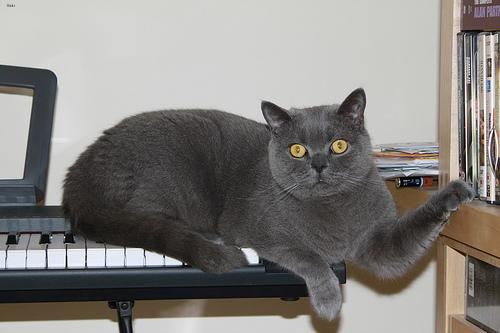

In [ ]:
img1 = Image.open(os.path.join(cat_folder, os.listdir(cat_folder)[11]))
img1

In [ ]:
for i in range(10):
  img = Image.open(os.path.join(cat_folder, os.listdir(cat_folder)[i]))
  print(img.size)
  print(img.mode)

(200, 179)
RGB
(332, 500)
RGB
(500, 375)
RGB
(500, 333)
RGB
(500, 375)
RGB
(500, 500)
RGB
(500, 333)
RGB
(500, 333)
RGB
(333, 500)
RGB
(375, 500)
RGB


In [ ]:
for i in range (10):
  img = Image.open(os.path.join(dog_folder, os.listdir(dog_folder)[i]))
  print(img.size)
  print(img.mode)

(500, 330)
RGB
(500, 375)
RGB
(500, 375)
RGB
(500, 354)
RGB
(246, 300)
RGB
(500, 375)
RGB
(500, 460)
RGB
(432, 348)
RGB
(500, 410)
RGB
(500, 329)
RGB


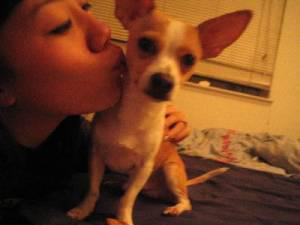

In [ ]:
img2 = Image.open(os.path.join(dog_folder, os.listdir(dog_folder)[17]))
img2

#*PREPROCESSING*

The dataset is already clean so we just continue our processing.

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/train',
    seed=123,
    image_size=(256, 256)
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/val',
    seed=123,
    image_size=(256, 256)
)

Found 275 files belonging to 2 classes.
Found 70 files belonging to 2 classes.


NORMALIZING

creating the normalization layer

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [ ]:
# Go through every batch in the training dataset. Normalize the images,
# but don't change the labels.
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

**DATA AUGMENTATION** applied only on training set

In [ ]:
data_augumentation = keras.Sequential(
    [
     tf.keras.layers.RandomFlip("horizontal"),
     tf.keras.layers.RandomRotation(0.1),
     tf.keras.layers.RandomZoom(0.1),
    ]
)

#**Building the model**

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False
# we remove the classification layer by freezing it

/tmp/ipykernel_545/2150067775.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model  = tf.keras.Sequential([
    data_augumentation,
    base_model,
    # takes all those feature maps and summarizes each one into a single value
    tf.keras.layers.GlobalAveragePooling2D(),
    # one output neuron
    tf.keras.layers.Dense(1, activation='sigmoid')
    ])

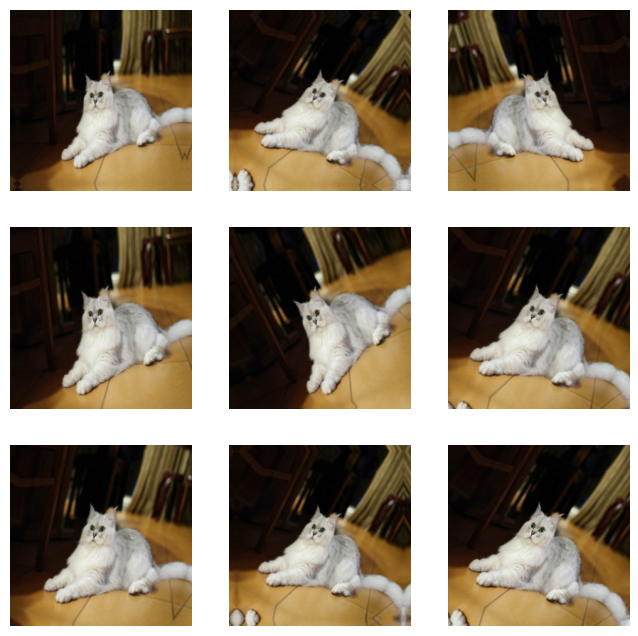

In [ ]:
import matplotlib.pyplot as plt
for images, labels in train_ds.take(1):
    first_image = images[0]

    plt.figure(figsize=(8, 8))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        augmented_image = data_augumentation(
            tf.expand_dims(first_image, 0),
            training=True
        )

        plt.imshow((augmented_image[0].numpy() * 255).astype("uint8"))
        plt.axis("off")

    plt.show()

**MODEL COMPILATION**

In [ ]:
from flax.nnx import optimizer
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 256, 256, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
import matplotlib.pyplot as plt
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)
plt.imshow(images[1])
print(labels[0].numpy())

**TRAINING**

In [ ]:
# callback function
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
# checkpoint
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

In [ ]:
# reducing learning rate
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=2,
    min_lr=6
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks = [
        early_stop,
        checkpoint,
        reduce_lr
                 ]
    )
# the model stops automatically when it stopped improving

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6323 - loss: 0.6241
Epoch 1: val_loss improved from None to 0.40177, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.6873 - loss: 0.5786 - val_accuracy: 0.8571 - val_loss: 0.4018 - learning_rate: 0.0010
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8277 - loss: 0.4132
Epoch 2: val_loss improved from 0.40177 to 0.28538, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.8509 - loss: 0.3860 - val_accuracy: 0.9714 - val_loss: 0.2854 - learning_rate: 0.0010
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9138 - loss: 0.2964
Epoch 3: val_loss improved from 0.28538 to 0.21673, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9345 - loss: 0.2719 - val_accuracy: 0.9857 - val_loss: 0.2167 - learning_rate: 0.0010
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9684 - loss: 0.2244
Epoch 4: val_loss improved from 0.21673 to 0.16984, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9673 - loss: 0.2071 - val_accuracy: 0.9714 - val_loss: 0.1698 - learning_rate: 0.0010
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9702 - loss: 0.1681
Epoch 5: val_loss improved from 0.16984 to 0.14462, saving model to best_model.h5


...


Epoch 6: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.9636 - loss: 0.1454 - val_accuracy: 0.9714 - val_loss: 0.1271 - learning_rate: 0.0010
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9455 - loss: 0.1413
Epoch 7: val_loss improved from 0.12708 to 0.11460, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9600 - loss: 0.1346 - val_accuracy: 0.9714 - val_loss: 0.1146 - learning_rate: 0.0010
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9729 - loss: 0.1125
Epoch 8: val_loss improved from 0.11460 to 0.10420, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9673 - loss: 0.1149 - val_accuracy: 0.9714 - val_loss: 0.1042 - learning_rate: 0.0010
Epoch 9/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9948 - loss: 0.0858
Epoch 9: val_loss improved from 0.10420 to 0.09658, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9891 - loss: 0.0956 - val_accuracy: 0.9714 - val_loss: 0.0966 - learning_rate: 0.0010
Epoch 10/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9743 - loss: 0.1111
Epoch 10: val_loss improved from 0.09658 to 0.09064, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9782 - loss: 0.0991 - val_accuracy: 0.9714 - val_loss: 0.0906 - learning_rate: 0.0010


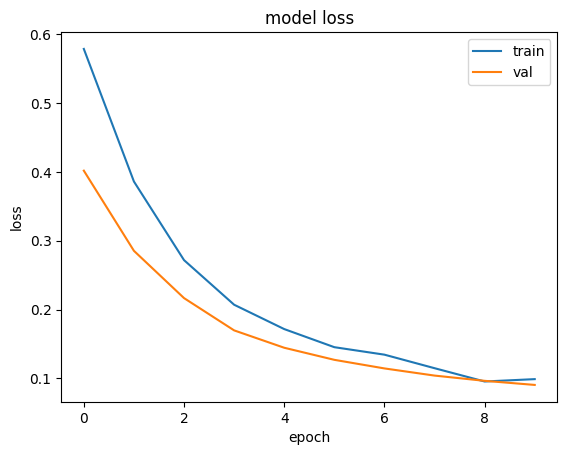

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')

FINE-TUNING

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
  layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks = [
        early_stop,
        checkpoint,
        reduce_lr
                 ]
    )


Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7422 - loss: 0.5594
Epoch 1: val_loss improved from 0.09064 to 0.08049, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 130s 9s/step - accuracy: 0.7818 - loss: 0.4978 - val_accuracy: 0.9714 - val_loss: 0.0805 - learning_rate: 1.0000e-05
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7812 - loss: 0.4365
Epoch 2: val_loss improved from 0.08049 to 0.07316, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 138s 9s/step - accuracy: 0.8036 - loss: 0.3938 - val_accuracy: 0.9714 - val_loss: 0.0732 - learning_rate: 1.0000e-05
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9076 - loss: 0.2155
Epoch 3: val_loss improved from 0.07316 to 0.06624, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 86s 9s/step - accuracy: 0.8473 - loss: 0.2968 - val_accuracy: 0.9714 - val_loss: 0.0662 - learning_rate: 1.0000e-05
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8343 - loss: 0.3131
Epoch 4: val_loss improved from 0.06624 to 0.06121, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 139s 9s/step - accuracy: 0.8509 - loss: 0.2799 - val_accuracy: 0.9714 - val_loss: 0.0612 - learning_rate: 1.0000e-05
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9050 - loss: 0.1904
Epoch 5: val_loss improved from 0.06121 to 0.05798, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
9/9 ━━━━━━━━━━━━━━━━━━━━ 147s 10s/step - accuracy: 0.9018 - loss: 0.1894 - val_accuracy: 0.9714 - val_loss: 0.0580 - learning_rate: 1.0000e-05


**EVALUATION**

*confusion matrix*

In [ ]:
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predicted_labels = (predictions > 0.5).astype(int).flatten()
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[22  2]
 [ 0 46]]


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=["Cat", "Dog"])
print(report)

              precision    recall  f1-score   support

         Cat       1.00      0.92      0.96        24
         Dog       0.96      1.00      0.98        46

    accuracy                           0.97        70
   macro avg       0.98      0.96      0.97        70
weighted avg       0.97      0.97      0.97        70



**PREDICTION**

In [ ]:
for images, labels in val_ds.take(1):
    predictions = model.predict(images)

    print("Predictions:")
    print(predictions[:10])

    print("\nTrue Labels:")
    print(labels[:10].numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predictions:
[[0.9959107 ]
 [0.00494725]
 [0.99444693]
 [0.99723434]
 [0.9978639 ]
 [0.9975772 ]
 [0.16656584]
 [0.00434817]
 [0.9921643 ]
 [0.00574184]]

True Labels:
[1 0 1 1 1 1 0 0 1 0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


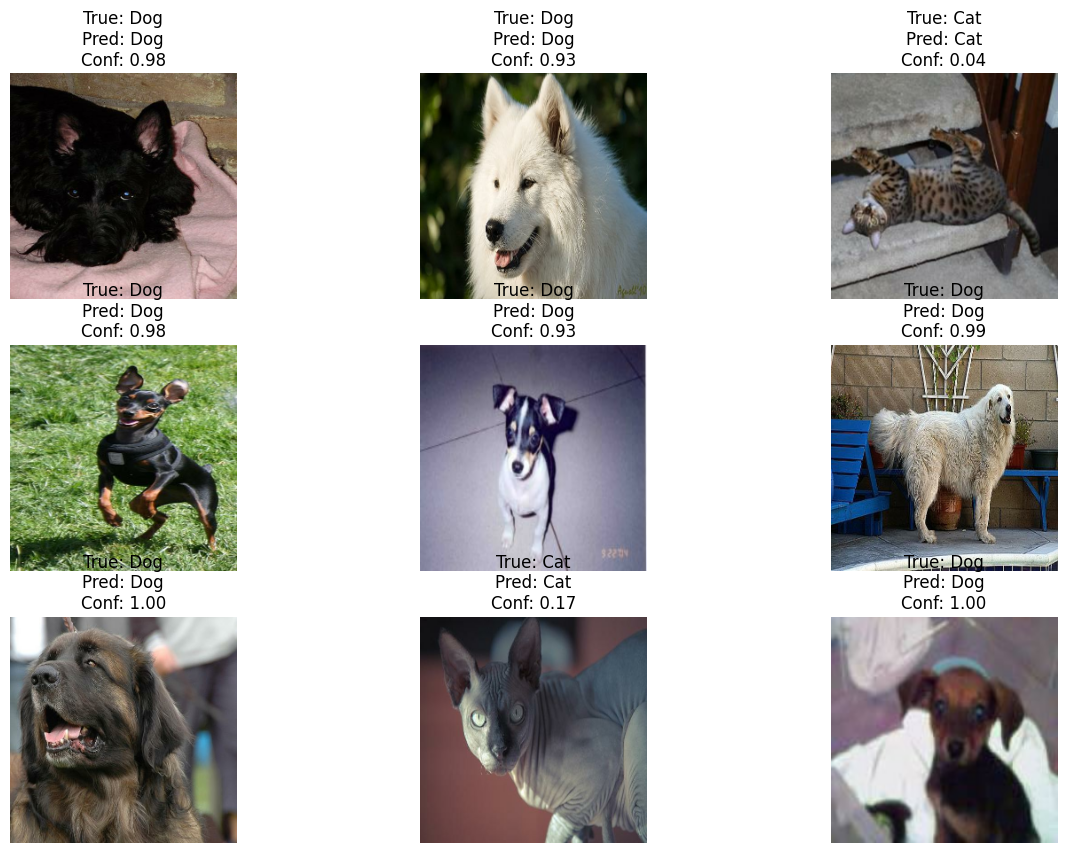

In [ ]:
import matplotlib.pyplot as plt

class_names = ["Cat", "Dog"]

for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = (predictions > 0.5).astype(int)

    plt.figure(figsize=(15, 10))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])

        true_label = class_names[labels[i].numpy()]
        pred_label = class_names[predicted_labels[i][0]]

        plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {predictions[i][0]:.2f}")
        plt.axis("off")

    plt.show()

#**SAVING / LOADING THE MODEL**

In [ ]:
model.save('cat_dog_classifier.keras')

In [ ]:
loaded_model = tf.keras.models.load_model('cat_dog_classifier.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 160 variables whereas the saved optimizer has 318 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
loaded_model.summary()

#**TESTING THE MODEL**

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dog.jpg to Dog.jpg


In [ ]:
img_path = '/content/Dog.jpg'

re-useable function

In [ ]:
def predict_image(image_path, model):
  img = image.load_img(image_path, target_size=(256, 256))
  plt.imshow(img)
  plt.axis('off')
  plt.show()
  img_array = image.img_to_array(img)
  img_array = img_array / 255.0
  img_array = np.expand_dims(img_array, axis=0)
  prediction = model.predict(img_array, verbose=0)
  probability = prediction[0][0]
  if probability > 0.5:
    print("🐶 Dog")
  else:
    print("🐱 Cat")
  print(f"Confidence: {probability:.2%}")

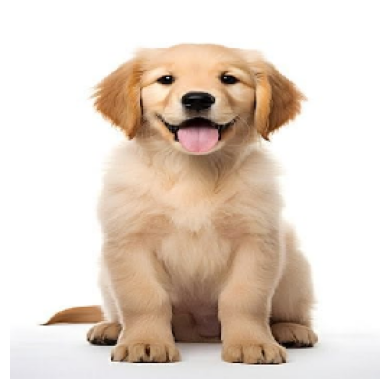

🐶 Dog
Confidence: 98.60%


In [ ]:
img_path = '/content/Dog.jpg'
predict_image(img_path, loaded_model)

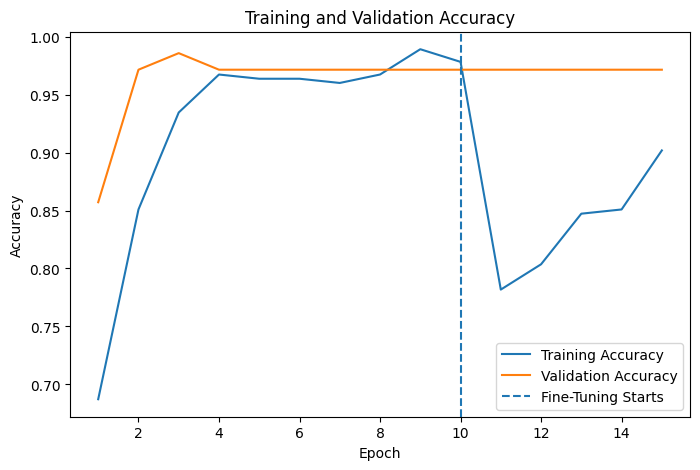

In [ ]:
import matplotlib.pyplot as plt

# Combine initial training and fine-tuning history
accuracy = history.history["accuracy"] + history_fine.history["accuracy"]
val_accuracy = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

# Accuracy Plot
plt.figure(figsize=(8, 5))

plt.plot(epochs, accuracy, label="Training Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")

plt.axvline(
    x=len(history.history["accuracy"]),
    linestyle="--",
    label="Fine-Tuning Starts"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

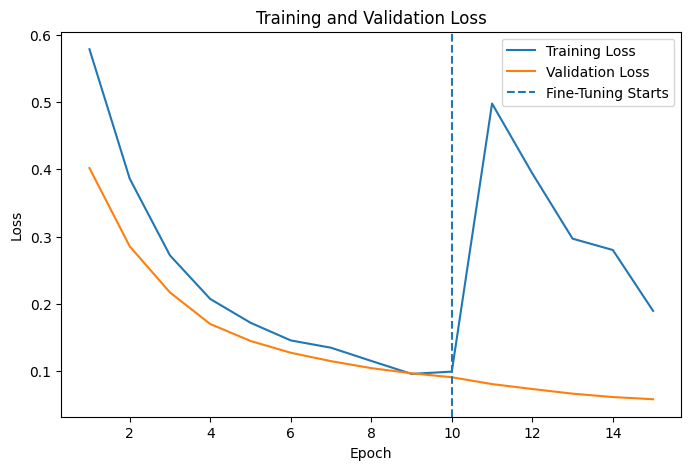

In [ ]:
# Loss Plot
plt.figure(figsize=(8, 5))

plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.axvline(
    x=len(history.history["loss"]),
    linestyle="--",
    label="Fine-Tuning Starts"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()